Dataset Shape : (8944, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  

Missing Values:

step              0
type              0
amount            0


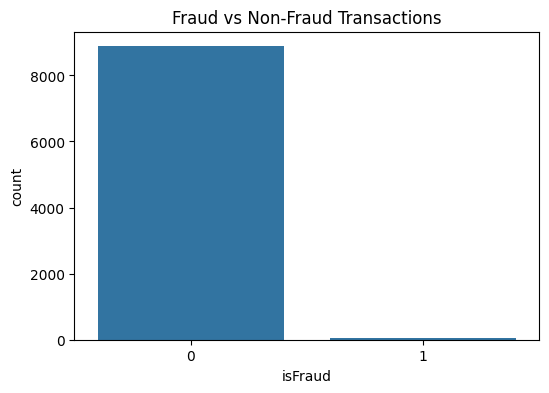

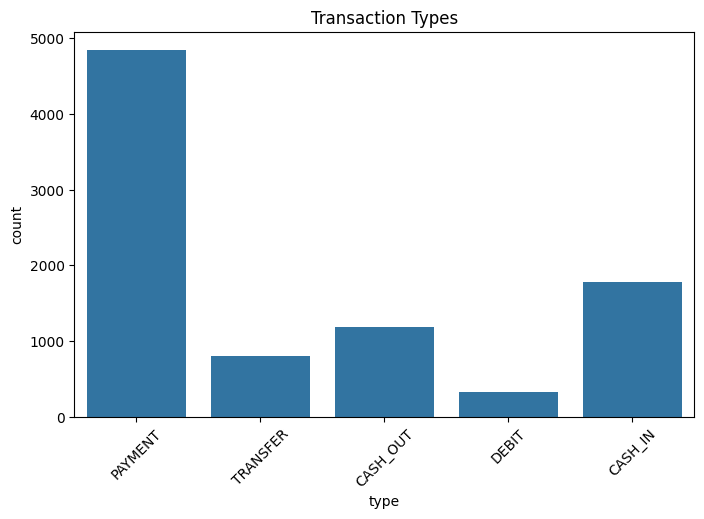

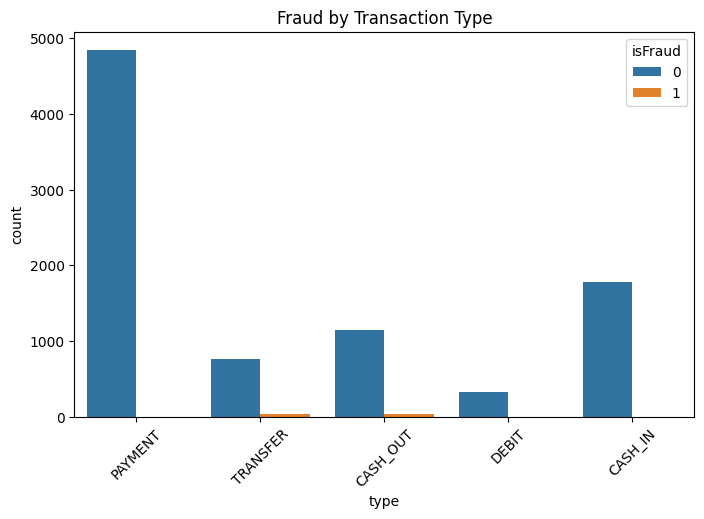

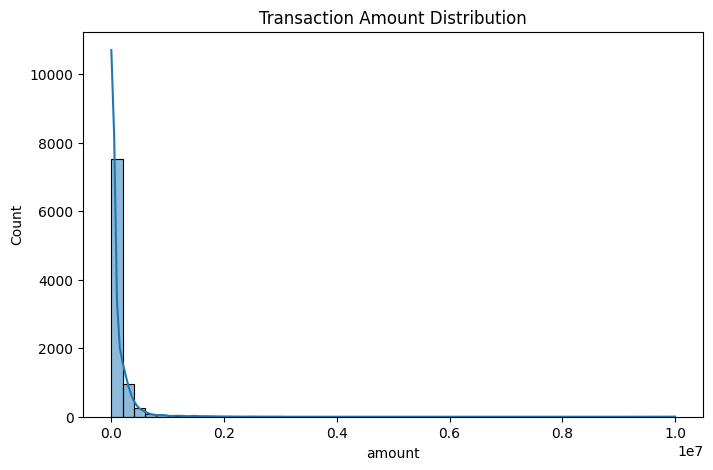

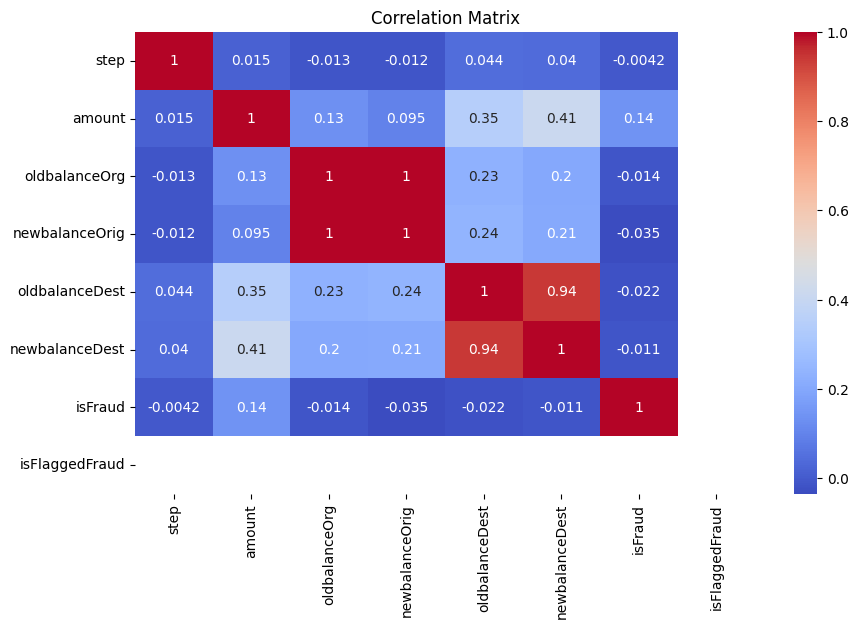


Logistic Regression
Accuracy : 0.9441
ROC-AUC  : 0.9369
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1776
           1       0.11      0.92      0.19        13

    accuracy                           0.94      1789
   macro avg       0.55      0.93      0.58      1789
weighted avg       0.99      0.94      0.97      1789


Decision Tree
Accuracy : 0.9939
ROC-AUC  : 0.6915
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1776
           1       0.62      0.38      0.48        13

    accuracy                           0.99      1789
   macro avg       0.81      0.69      0.74      1789
weighted avg       0.99      0.99      0.99      1789


Random Forest
Accuracy : 0.9972
ROC-AUC  : 0.9995
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1776
           1       1.00      0.62      0.76        13

    accuracy           

In [3]:
# ==========================================================
# FRAUD DETECTION PROJECT
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, roc_auc_score, classification_report














In [4]:
# ==========================================================
# LOAD DATASET
# ==========================================================
df = pd.read_csv("fraud_detection_dataset.csv")

print("Dataset Shape :", df.shape)
print(df.head())


Dataset Shape : (8944, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  



Missing Values:

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Data Types:

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Fraud Distribution:

isFraud
0    8878
1      66
Name: count, dtype: int64


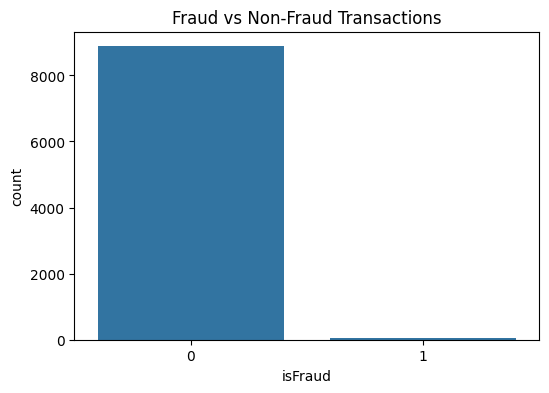

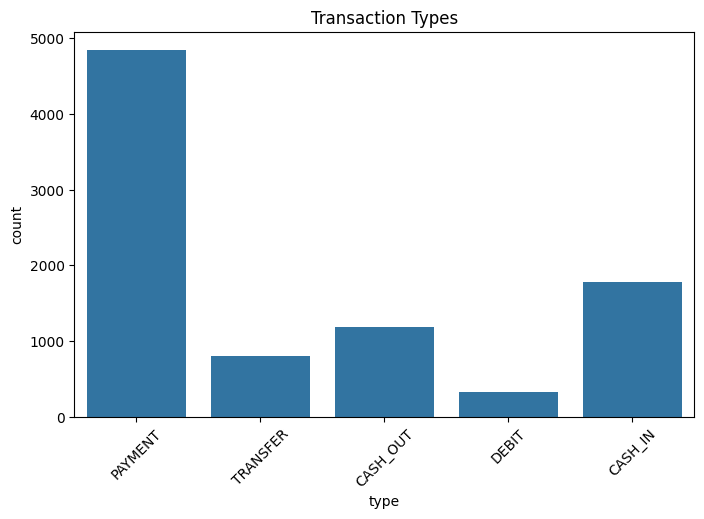

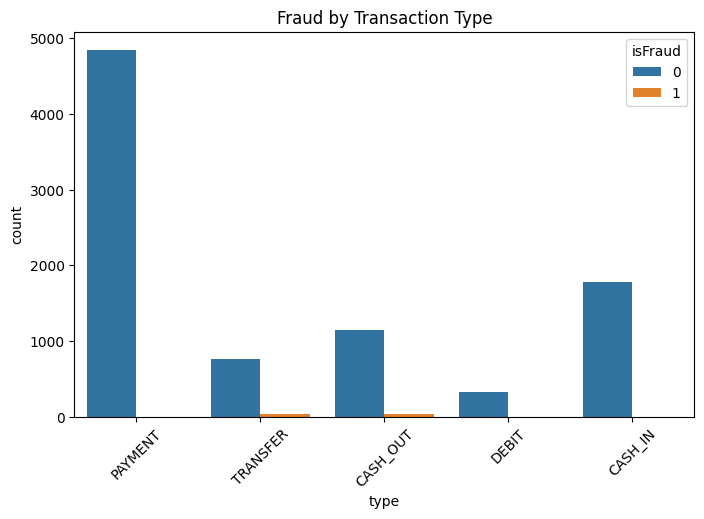

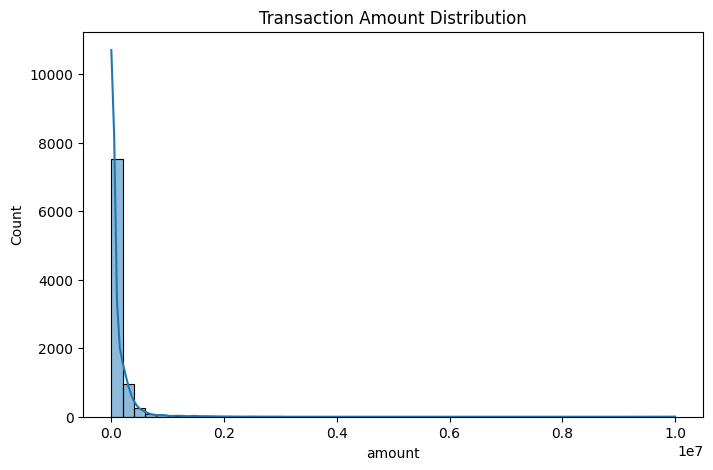

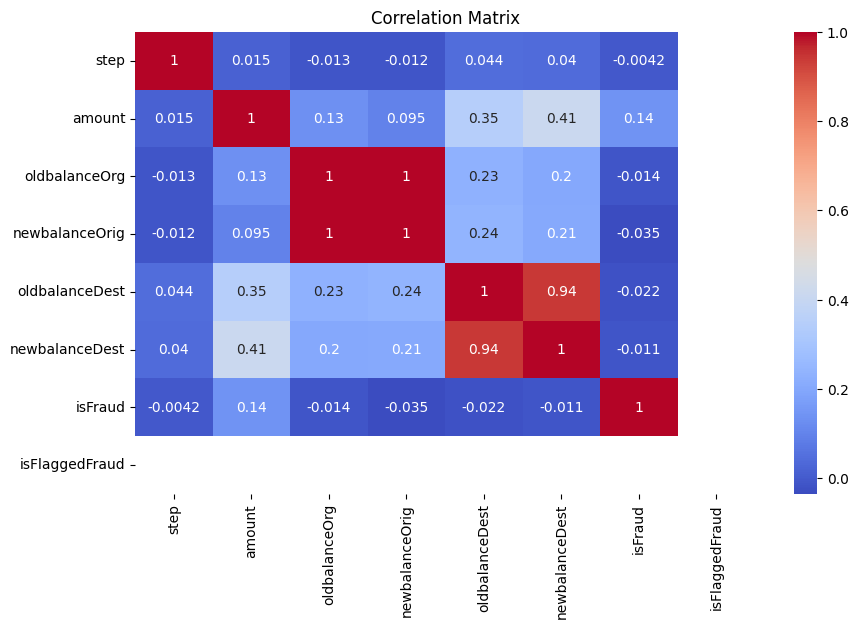

In [5]:
# ==========================================================
# EDA SECTION
# ==========================================================

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nData Types:\n")
print(df.dtypes)

print("\nFraud Distribution:\n")
print(df["isFraud"].value_counts())

# Fraud Count Plot
plt.figure(figsize=(6,4))
sns.countplot(x="isFraud", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

# Transaction Type Distribution
plt.figure(figsize=(8,5))
sns.countplot(x="type", data=df)
plt.title("Transaction Types")
plt.xticks(rotation=45)
plt.show()

# Fraud by Type
plt.figure(figsize=(8,5))
sns.countplot(x="type", hue="isFraud", data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

# Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["amount"], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


In [6]:
# ==========================================================
# FEATURE / TARGET
# ==========================================================
X = df.drop(columns=["isFraud", "nameOrig", "nameDest"])
y = df["isFraud"]

categorical = ["type"]
numeric = [col for col in X.columns if col not in categorical]


In [7]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [8]:
# ==========================================================
# PREPROCESSING
# ==========================================================
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num", "passthrough", numeric)
])

In [9]:
# ==========================================================
# MODELS
# ==========================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier()
}

results = []

best_model = None
best_auc = 0
best_name = ""

In [10]:
# ==========================================================
# TRAIN + COMPARE
# ==========================================================
for name, model in models.items():

    pipeline = Pipeline([
        ("prep", preprocessor),
        ("clf", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, auc])

    print(f"\n{name}")
    print("Accuracy :", round(acc,4))
    print("ROC-AUC  :", round(auc,4))
    print(classification_report(y_test, y_pred))

    if auc > best_auc:
        best_auc = auc
        best_model = pipeline
        best_name = name



Logistic Regression
Accuracy : 0.9441
ROC-AUC  : 0.9369
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1776
           1       0.11      0.92      0.19        13

    accuracy                           0.94      1789
   macro avg       0.55      0.93      0.58      1789
weighted avg       0.99      0.94      0.97      1789


Decision Tree
Accuracy : 0.9944
ROC-AUC  : 0.6917
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1776
           1       0.71      0.38      0.50        13

    accuracy                           0.99      1789
   macro avg       0.85      0.69      0.75      1789
weighted avg       0.99      0.99      0.99      1789


Random Forest
Accuracy : 0.9966
ROC-AUC  : 0.9993
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1776
           1       1.00      0.54      0.70        13

    accuracy           

In [11]:
# ==========================================================
# RESULTS TABLE
# ==========================================================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC_AUC"])
print("\nModel Comparison:\n")
print(results_df)


Model Comparison:

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.944103  0.936894
1        Decision Tree  0.994410  0.691745
2        Random Forest  0.996646  0.999329
3    Gradient Boosting  0.997205  0.999610


In [12]:
# ==========================================================
# SAVE BEST MODEL
# ==========================================================
joblib.dump(best_model, "best_fraud_model.pkl")

print("\nBest Model :", best_name)
print("Saved File : best_fraud_model.pkl")


Best Model : Gradient Boosting
Saved File : best_fraud_model.pkl
